# Bike Rental Demand Prediction

## Business Context

A bike-sharing operator needs to anticipate demand so that bikes and docking capacity can be positioned where they are most useful. Demand changes with weather, seasonality, time of day, and whether a day falls on a weekend.

This notebook uses historical rental and weather data to estimate the number of rentals under a given set of conditions. The analysis compares an interpretable linear regression with regression trees and uses out-of-sample performance to choose the stronger approach.

## Objective

The objective is to build a demand-prediction model that can support operational planning while remaining understandable enough to explain the main drivers of rental volume. The workflow also demonstrates how a point forecast can be translated into a probability-based business question.

### Step 1: Import Required Libraries

Load the packages used for data exploration, statistical regression, probability calculations, tree-based modeling, and evaluation.

In [1]:
!pip install skimpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.6 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you 

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import norm
from skimpy import skim
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, plot_tree

### Step 2: Load and Inspect the Data

Load the rental and weather dataset and inspect the first and last observations. This establishes the available time, calendar, and weather variables before feature selection begins.

In [2]:
df = pd.read_csv('/data/rentals_weather.csv')

In [3]:
df.head(6)

,rentals,month,day,hour,day_of_week,weekend,temp,temp_wb,rel_humidity,windspeed,precipitation
0,4,1,1,0,Mon,0,2,0,59,16,0.0
1,6,1,1,1,Mon,0,1,0,59,11,0.0
2,6,1,1,2,Mon,0,1,-1,54,21,0.0
3,1,1,1,5,Mon,0,0,-2,54,18,0.0
4,3,1,1,6,Mon,0,0,-2,54,15,0.0
5,3,1,1,7,Mon,0,0,-2,54,11,0.0


In [4]:
df.tail(6)

,rentals,month,day,hour,day_of_week,weekend,temp,temp_wb,rel_humidity,windspeed,precipitation
8597,69,12,31,18,Mon,0,42,37,60,10,0.00
8598,36,12,31,19,Mon,0,39,36,76,13,0.02
8599,25,12,31,20,Mon,0,38,36,86,14,0.04
8600,13,12,31,21,Mon,0,37,36,89,15,0.07
8601,6,12,31,22,Mon,0,38,37,89,14,0.09
8602,7,12,31,23,Mon,0,39,38,89,17,0.19


### Step 3: Define Categorical Variables

Convert month, day, hour, day of week, and weekend indicators to categorical types. This allows the statistical models to treat these fields as discrete effects rather than continuous numeric relationships.

In [5]:
categorical_variables = ['month','day','hour','day_of_week','weekend']
df[categorical_variables] = df[categorical_variables].astype('category')

In [6]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 8603   │ │ int64       │ 5     │ │ month                 │                                │
│ │ Number of columns │ 11     │ │ category    │ 5     │ │ day                   │                                │
│ └───────────────────┴────────┘ │ float64     │ 1     │ │ hour                  │                                │
│                                └─────────────┴───────┘ │ day_of_week           │                                │
│                                                        │ weekend               │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column             ┃ NA   ┃ NA %   ┃ mean       ┃ sd         ┃ p0  ┃ p25   ┃ p50  ┃ p75  ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ rentals            │    0 │      0 │      205.1 │      227.1 │   1 │    32 │  120 │  306 │  1299 │   █▃▁   │  │
│ │ temp               │    0 │      0 │      53.21 │      18.29 │  -2 │    38 │   52 │   69 │    97 │  ▂█▆▇▂  │  │
│ │ temp_wb            │    0 │      0 │      47.84 │      16.91 │  -3 │    34 │   48 │   62 │    81 │  ▂█▇█▅  │  │
│ │ rel_humidity       │    0 │      0 │      67.11 │      18.92 │  16 │    53 │   68 │   84 │   100 │ ▁▃▇█▇▇  │  │
│ │ windspeed          │    0 │      0 │       11.1 │      5.455 │   0 │     7 │   10 │   14 │    48 │   ▄█▂   │  │
│ │ precipitation      │    0 │      0 │    0.00544 │    0.03407 │   0 │     0 │    0 │    0 │  1.12 │    █    │  │
│ └────────────────────┴──────┴────────┴────────────┴────────────┴─────┴───────┴──────┴──────┴───────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                           ┃ NA        ┃ NA %           ┃ ordered               ┃ unique             ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩  │
│ │ month                            │         0 │              0 │ False                 │                 12 │  │
│ │ day                              │         0 │              0 │ False                 │                 31 │  │
│ │ hour                             │         0 │              0 │ False                 │                 24 │  │
│ │ day_of_week                      │         0 │              0 │ False                 │                  7 │  │
│ │ weekend                          │         0 │              0 │ False                 │                  2 │  │
│ └──────────────────────────────────┴───────────┴────────────────┴───────────────────────┴────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

### Step 4: Explore Rental Demand

Start with the overall rental distribution to understand its scale and variability. The stored summary shows an average of about **205 rentals** with a standard deviation of about **227**, indicating substantial variation across observations.

Text(0, 0.5, 'Number of Data Points')

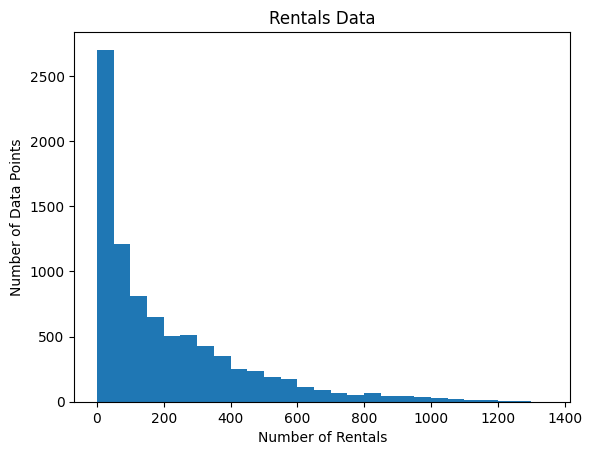

In [7]:
plt.hist(df['rentals'], bins = range(0,1400,50))
plt.title('Rentals Data')
plt.xlabel('Number of Rentals')
plt.ylabel('Number of Data Points')

In [8]:
print("Average no. of Rentals: "+str(np.mean(df['rentals']))+" Standard Dev: "+str(np.std(df['rentals'])))

Average no. of Rentals: 205.08578402882716 Standard Dev: 227.03926517480508


Inspect rental demand at a fixed temperature of 25°F. Holding one condition constant reduces some of the variability and helps illustrate why weather and calendar features can improve demand prediction.

Text(0, 0.5, 'Number of Data Points')

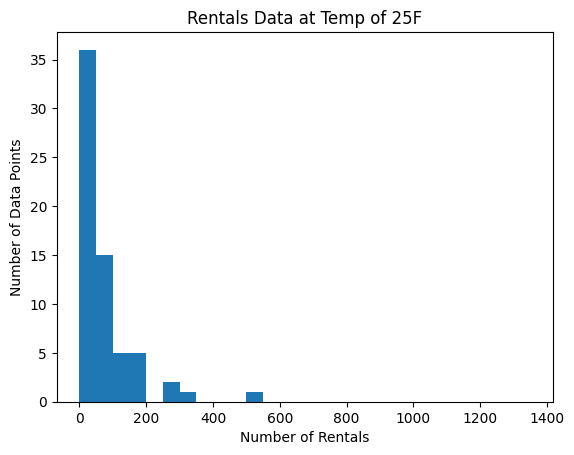

In [9]:
df_cold = df[df['temp']==25]
plt.hist(df_cold['rentals'], bins = range(0,1400,50))
plt.title('Rentals Data at Temp of 25F')
plt.xlabel('Number of Rentals')
plt.ylabel('Number of Data Points')

At 25°F, the stored data show an average of about **72.6 rentals** and a standard deviation of about **90.5**. The reduction in variability suggests that temperature contains useful information, although it is clearly not the only driver of demand.

In [10]:
print("Average no. of Rentals at 25F: "+str(np.mean(df_cold['rentals']))+" Standard Dev: "+str(np.std(df_cold['rentals'])))

Average no. of Rentals at 25F: 72.55384615384615 Standard Dev: 90.4802623218041


Use scatter plots to examine relationships between rental volume and candidate predictors. Hour of day is especially important from an operational perspective because commuting and leisure patterns can create sharp demand changes even under similar weather conditions.

Text(0, 0.5, '# Rentals')

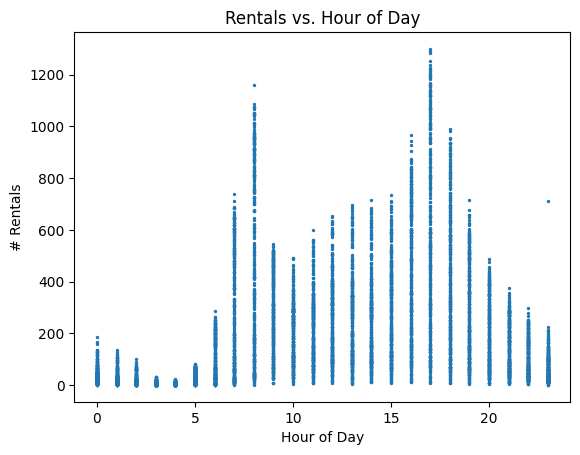

In [11]:
plt.scatter(df['hour'],df['rentals'],s=2)
plt.title('Rentals vs. Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('# Rentals')

Compare rentals with temperature. The raw observations remain noisy, but the mean rental level shows a visible upward trend as temperature increases. This motivates testing a linear regression as an interpretable baseline.

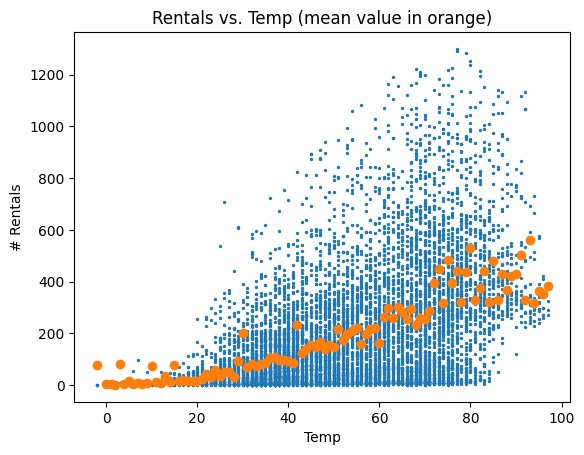

In [12]:
plt.scatter(df['temp'],df['rentals'],s=2)
plt.title('Rentals vs. Temp (mean value in orange)')
plt.xlabel('Temp')
plt.ylabel('# Rentals')
plt.scatter(df['temp'].unique(),df.groupby('temp')['rentals'].mean())

The exploratory plots suggest that a linear model is a reasonable starting point, but feature selection still matters. The next steps check correlation and statistical contribution so that redundant variables do not make the regression unnecessarily unstable.

### Step 5: Check Correlation and Redundancy

Inspect correlations among the continuous weather variables before fitting the final regression. Strong correlation between predictors can create multicollinearity, which makes coefficients harder to interpret and can increase estimation variance.

The goal is to retain variables that add distinct predictive information rather than keeping multiple measurements of nearly the same underlying condition.

In [13]:
df[['temp',	'temp_wb',	'rel_humidity',	'windspeed',	'precipitation']].corr()

,temp,temp_wb,rel_humidity,windspeed,precipitation
temp,1.000000,0.977801,0.126377,-0.148411,0.018469
temp_wb,0.977801,1.000000,0.319822,-0.188347,0.057638
rel_humidity,0.126377,0.319822,1.000000,-0.218430,0.206801
windspeed,-0.148411,-0.188347,-0.218430,1.000000,0.069177
precipitation,0.018469,0.057638,0.206801,0.069177,1.000000


Wet-bulb temperature is highly correlated with temperature, so using both would add substantial redundancy. Relative humidity, wind speed, and precipitation show weaker relationships with one another and are tested more directly in the regression.

A random feature is also introduced as a reference point. If a candidate variable behaves like noise, adding it should not materially improve explanatory power. This provides a practical benchmark for deciding whether additional predictors are useful.

In [14]:
est = ols(formula="rentals ~ temp + rel_humidity", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     1742.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -57416.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8600   BIC:                         1.149e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       52.9562      9.175      5.772   

In [15]:
random_data = np.random.rand(len(df['rentals']))
df['random'] = random_data
df.head(6)

,rentals,month,day,hour,day_of_week,weekend,temp,temp_wb,rel_humidity,windspeed,precipitation,random
0,4,1,1,0,Mon,0,2,0,59,16,0.0,0.409165
1,6,1,1,1,Mon,0,1,0,59,11,0.0,0.871453
2,6,1,1,2,Mon,0,1,-1,54,21,0.0,0.340494
3,1,1,1,5,Mon,0,0,-2,54,18,0.0,0.873978
4,3,1,1,6,Mon,0,0,-2,54,15,0.0,0.343743
5,3,1,1,7,Mon,0,0,-2,54,11,0.0,0.749041


In [16]:
df['rentals'].corr(df['random'])

np.float64(0.0057156933398709595)

Text(0, 0.5, '# Rentals')

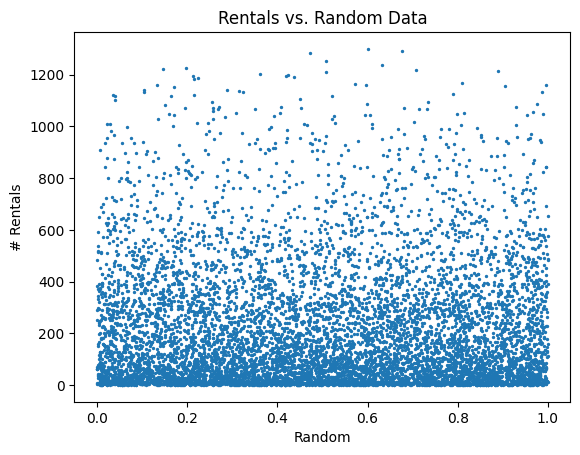

In [17]:
plt.scatter(df['random'],df['rentals'],s=2)
plt.title('Rentals vs. Random Data')
plt.xlabel('Random')
plt.ylabel('# Rentals')

In [18]:
est = ols(formula="rentals ~ temp + rel_humidity + random", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     1161.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -57416.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8599   BIC:                         1.149e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       51.0201      9.766      5.224   

In [19]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     1168.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -57410.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8599   BIC:                         1.149e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        48.6214      9.242      5.261

In [20]:
est = ols(formula="rentals ~ temp + rel_humidity + windspeed", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     1161.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -57416.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8599   BIC:                         1.149e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       48.3642     11.325      4.271   

In [21]:
est = ols(formula="rentals ~ temp + rel_humidity + windspeed + precipitation", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     876.1
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -57409.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8598   BIC:                         1.149e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        40.8156     11.488      3.553

### Step 6: Assess Variable Contribution

Use regression significance and model fit to determine which variables contribute useful signal. Categorical variables are represented through indicator variables so their effect can be evaluated within the regression.

The analysis also compares day-of-week and weekend information. Since weekend captures much of the same behavior with fewer parameters, the simpler representation is preferred when the additional day-level detail does not improve the model meaningfully.

In [22]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + month", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     269.1
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -57315.
No. Observations:                8603   AIC:                         1.147e+05
Df Residuals:                    8588   BIC:                         1.148e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        56.1751     12.252      4.585

In [23]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + day", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     108.5
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:15   Log-Likelihood:                -57378.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8569   BIC:                         1.151e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        51.3243     14.768      3.475

In [24]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + hour", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     594.7
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:15   Log-Likelihood:                -54446.
No. Observations:                8603   AIC:                         1.089e+05
Df Residuals:                    8576   BIC:                         1.091e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -150.0144      9.821    -15.275

In [25]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + day_of_week", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     420.7
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:15   Log-Likelihood:                -57309.
No. Observations:                8603   AIC:                         1.146e+05
Df Residuals:                    8593   BIC:                         1.147e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             72.7698     10

In [26]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + weekend", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     946.0
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:15   Log-Likelihood:                -57311.
No. Observations:                8603   AIC:                         1.146e+05
Df Residuals:                    8598   BIC:                         1.147e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        74.2324      9.315      7.969

The feature review suggests that `day` adds little value and that `day_of_week` overlaps strongly with the simpler `weekend` indicator. To reduce redundancy and keep the model easier to explain, the final linear regression excludes `temp_wb`, `windspeed`, `day`, and `day_of_week`.

This is a useful modeling trade-off: a slightly simpler feature set can improve interpretability and robustness without sacrificing meaningful business signal.

### Step 7: Train the Linear Regression

Create a 70/30 train-test split and fit the regression using the selected predictors. The training set is used to estimate coefficients, while the held-out set provides an out-of-sample check of predictive performance.

In [27]:
df = df.drop(columns=['random'])
df_final = df.drop(columns=['temp_wb','windspeed','day','day_of_week'])

In [28]:
df_train, df_test = train_test_split(df_final, test_size=0.3, shuffle=True, random_state=42)

X = df_train.copy()
y = X.pop('rentals')
X_test = df_test.copy()
y_test = X_test.pop('rentals')


In [29]:
my_formula = 'rentals ~ ' + '+'.join(df_train.columns[1:])

est = ols(formula = my_formula, data=df_train).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     339.7
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:55:15   Log-Likelihood:                -37811.
No. Observations:                6022   AIC:                         7.570e+04
Df Residuals:                    5983   BIC:                         7.596e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -89.7447     13.190     -6.804

### Step 8: Test the Linear Regression

Evaluate the fitted model on the test set using out-of-sample R-squared. The stored result is approximately **0.680**, meaning the model explains a substantial share of rental variation on unseen observations while leaving meaningful residual uncertainty.

In [30]:
test_pred = est.predict(df_test)
print('OOS R-squared: '+str(r2_score(df_test['rentals'],test_pred)))

OOS R-squared: 0.679515733386181


### Step 9: Translate the Forecast into a Business Probability

A point forecast is useful, but operations teams often need to understand uncertainty as well. Use the model residual standard deviation together with a point estimate to approximate rental demand with a Normal distribution for a defined set of conditions.

This turns the regression into a decision-oriented question such as: *What is the probability that demand will exceed a specific operational threshold?*

In [31]:
# Standard deviation
print(np.sqrt(est.mse_resid))

129.4303985529663


Estimate demand for the following scenario: temperature of 60°F, relative humidity of 50%, precipitation of 0.09, weekend conditions, 3:00 PM, and June.

The stored point estimate is approximately **275.4 rentals**.

In [32]:
print('y_pred = -89.7447 + 3.3416*60 - 1.3772*50 - 398.0061*0.09 - 61.6098*1 + 209.5526*1 + 121.4227*1 = ' + str(-89.7447 + 3.3416*60 - 1.3772*50 - 398.0061*0.09 - 61.6098*1 + 209.5526*1 + 121.4227*1))

y_pred = -89.7447 + 3.3416*60 - 1.3772*50 - 398.0061*0.09 - 61.6098*1 + 209.5526*1 + 121.4227*1 = 275.436251


Using the point estimate of about **275.4** and the residual standard deviation of about **129.4**, the notebook estimates the probability that demand exceeds 400 rentals under the specified conditions.

In [33]:
print('Probability of at least 400 rentals when the conditions are met: '+str(1-norm.cdf(400,loc=275.44,scale=129.43)))

Probability of at least 400 rentals when the conditions are met: 0.16793101421656675


The resulting probability is approximately **16.8%**. This is more actionable than a point forecast alone: an operations team can compare the probability of exceeding capacity with the cost of repositioning bikes or adding buffer capacity.

The second half of the notebook tests whether a regression tree can improve predictive performance by capturing non-linear interactions among weather and calendar variables.

### Step 10: Prepare the Data for Regression Trees

Create the same 70/30 train-test structure used for linear regression, define an out-of-sample R-squared function, and prepare a tree visualization helper. Keeping the evaluation framework consistent makes the model comparison more meaningful.

In [34]:
df_train, df_test = train_test_split(df, test_size=0.3, shuffle=True, random_state=42)

X = df_train.copy()
y = X.pop('rentals')
X_test = df_test.copy()
y_test = X_test.pop('rentals')

In [35]:
def OSR2(y_pred, y_true, training_mean):
  '''
  Calculates out-of-sample R-squared
  '''
  baseline_error = np.sum(np.square((training_mean - y_true)))
  model_error = np.sum(np.square((y_pred - y_true)))
  return 1.0 - model_error/baseline_error

In [36]:
def viz_tree(tree, font=12, figsize=(16,10)):
  '''
  draws a classification tree
  '''
  plt.figure(figsize=figsize)  # set plot size (denoted in inches)
  _ = plot_tree(tree,
                feature_names=X.columns,
                filled=True,
                fontsize=font)

### Step 11: Encode Features for the Regression Tree

One-hot encode the categorical variables before training the tree. This produces a numeric feature matrix while preserving the information contained in month, hour, day of week, and weekend categories.

In [37]:
tree = DecisionTreeRegressor(random_state=42)

In [38]:
X = pd.get_dummies(X, columns = categorical_variables)
X_test = pd.get_dummies(X_test, columns = categorical_variables)

In [39]:
X.head()

,temp,temp_wb,rel_humidity,windspeed,precipitation,month_1,month_2,month_3,month_4,month_5,...,hour_23,day_of_week_Fri,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,weekend_0,weekend_1
5156,84,74,61,10,0.00,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
6290,70,68,90,5,0.00,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2646,57,49,53,13,0.00,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
439,46,39,51,5,0.00,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1379,41,39,86,46,0.03,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False


Fit the regression tree using the default model settings. This provides a high-capacity baseline before any regularization is applied.

In [40]:
tree.fit(X,y)

DecisionTreeRegressor(random_state=42)

### Step 12: Compare Training and Test Performance

Measure model fit on both the training and test sets. The default tree reaches **100% training R²** and approximately **0.782 test OSR²**.

In [41]:
print('The OSR2 for the train data set is: '+str(OSR2(tree.predict(X), y, y.mean())))

The OSR2 for the train data set is: 1.0


In [42]:
print('The OSR2 for the test data set is: '+str(OSR2(tree.predict(X_test), y_test, y.mean())))

The OSR2 for the test data set is: 0.7824430330733544


The gap between perfect training fit and lower test performance is a clear sign of overfitting. The tree has learned the training observations extremely closely, so the next step is to reduce complexity and improve generalization.

In [43]:
tree.tree_.node_count, tree.tree_.max_depth

(11301, 47)

The default tree contains **11,301 nodes** and reaches a maximum depth of **47**. Cost-complexity pruning is used to penalize unnecessary splits and search for a smaller tree with stronger out-of-sample performance.

The pruning workflow generates candidate trees, evaluates each on held-out data, and selects the complexity level that best balances fit and generalization.

### Step 13: Generate Pruned Trees

Calculate the cost-complexity pruning path and create candidate values of `ccp_alpha`. Each value corresponds to a different trade-off between tree size and fit.

In [44]:
tree = DecisionTreeRegressor(random_state=42)

In [45]:
path = tree.cost_complexity_pruning_path(X,y)

In [46]:
alphas = path.ccp_alphas

In [47]:
len(alphas)

5186

The full pruning path contains thousands of candidate values, so a smaller evenly sampled subset is used for model comparison. This keeps the experiment computationally manageable while still covering a wide range of tree sizes.

In [48]:
alphas_small = alphas[::100]
alphas_small = alphas_small[::-1]

In [49]:
r2_all = []
osr2_all = []
node_counts = []

for alpha in alphas_small:
  tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
  tree.fit(X,y)
  y_pred = tree.predict(X)
  r2_all.append(OSR2(y_pred, y, y.mean()))
  y_pred = tree.predict(X_test)
  osr2_all.append(OSR2(y_pred, y_test, y.mean()))
  node_counts.append(tree.tree_.node_count)

### Step 14: Evaluate the Pruned Trees

Fit the sampled candidate trees and compare training R-squared with test OSR-squared. The goal is to identify the point where additional tree complexity stops improving generalization.

Text(0.5, 1.0, 'Prediction quality vs tree size')

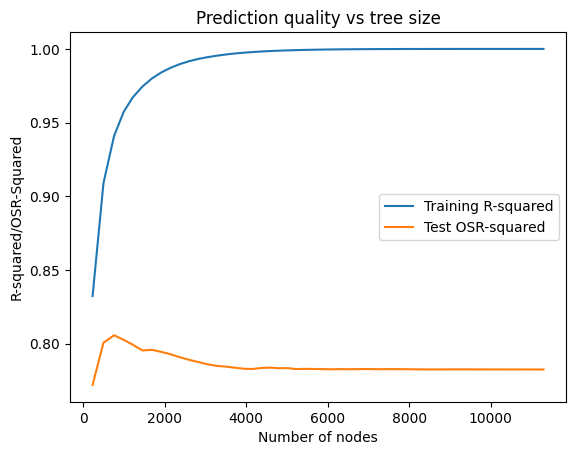

In [50]:
plt.plot(node_counts, r2_all, label='Training R-squared')
plt.plot(node_counts, osr2_all, label='Test OSR-squared')
plt.legend()
plt.xlabel('Number of nodes')
plt.ylabel('R-squared/OSR-Squared')
plt.title('Prediction quality vs tree size')

The comparison shows the expected bias-variance pattern: training fit continues to improve as the tree grows, while test performance peaks and then declines. This is the practical signal used to choose the pruned model.

### Step 15: Select the Best Pruned Tree

Identify the `ccp_alpha` associated with the highest test OSR-squared and refit the tree using that pruning level.

In [51]:
opt_idx = np.argmax(osr2_all)

In [52]:
alphas_small[opt_idx]

np.float64(9.300806457131927)

In [53]:
tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alphas_small[opt_idx])
tree.fit(X,y)

DecisionTreeRegressor(ccp_alpha=np.float64(9.300806457131927), random_state=42)

In [54]:
tree.tree_.node_count, tree.tree_.max_depth

(753, 30)

The selected tree is substantially smaller than the original, with **753 nodes** and a maximum depth of **30**. It remains complex, but pruning removes a large amount of unnecessary structure while improving out-of-sample performance.

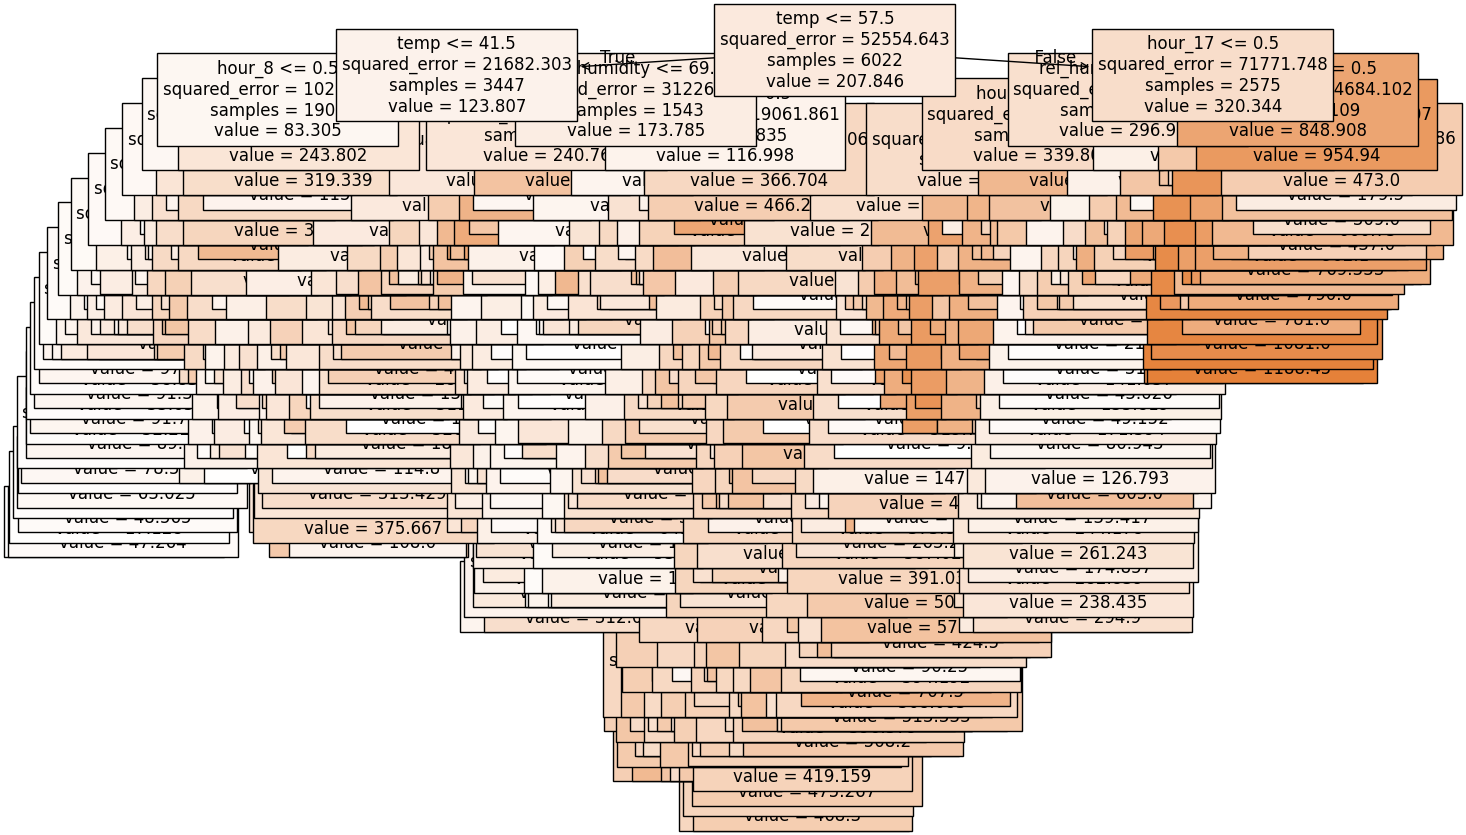

In [55]:
viz_tree(tree)

### Step 16: Confirm Out-of-Sample Performance

Evaluate the selected pruned tree on the held-out test data. The stored OSR-squared is approximately **0.806**, higher than both the unpruned tree and the linear regression.

In [56]:
OSR2(tree.predict(X_test), y_test, y.mean())

np.float64(0.8056467590667243)

## Conclusions

### Technical Takeaways

The model comparison shows a clear progression:

- Linear regression: test R² of approximately **0.680**.
- Unpruned regression tree: test OSR² of approximately **0.782**, but with severe overfitting and 11,301 nodes.
- Pruned regression tree: test OSR² of approximately **0.806**, with a much smaller 753-node structure.

For this dataset, the pruned tree provides the strongest out-of-sample performance. The linear regression remains valuable because its coefficients are easier to explain and it can be used to translate a forecast into an interpretable probability under an explicit residual assumption.

A stronger production comparison would use repeated cross-validation or an out-of-time split, inspect residual behavior by season and hour, and evaluate error metrics such as MAE or RMSE alongside R².

### Business Takeaways

The models can support bike rebalancing, staffing, and capacity planning by estimating expected rental demand from weather and calendar conditions. The probability example is especially useful operationally because it frames uncertainty in terms of the chance of exceeding a demand threshold.

The best predictive model is not automatically the only model the business should use. The pruned tree offers better predictive performance, while the linear regression offers clearer explanation and easier scenario analysis. The right choice depends on whether the immediate decision prioritizes forecast accuracy, interpretability, or both.

### Next Steps

A production system should incorporate recent demand history, station-level location features, holidays and events, and time-series validation. Prediction intervals should also be calibrated empirically rather than relying only on a Normal residual approximation.

The notebook code contains the full feature-selection, regression, probability, tree-pruning, and model-comparison workflow for further experimentation.